In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3703 - loss: 3.6526 - val_accuracy: 0.4171 - val_loss: 1.0872
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5010 - loss: 3.6236 - val_accuracy: 0.5312 - val_loss: 0.9573
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5898 - loss: 3.1437 - val_accuracy: 0.5707 - val_loss: 2.2746
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6268 - loss: 2.6948 - val_accuracy: 0.5815 - val_loss: 2.5073
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6719 - loss: 2.2196 - val_accuracy: 0.5965 - val_loss: 3.3960
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MODEL EVALUATION METRICS
Accuracy:  0.5465
Precision: 0.5437
Recall:    0.5465
F1-Score:  0.5437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.62      0.70      0.66      1243
  

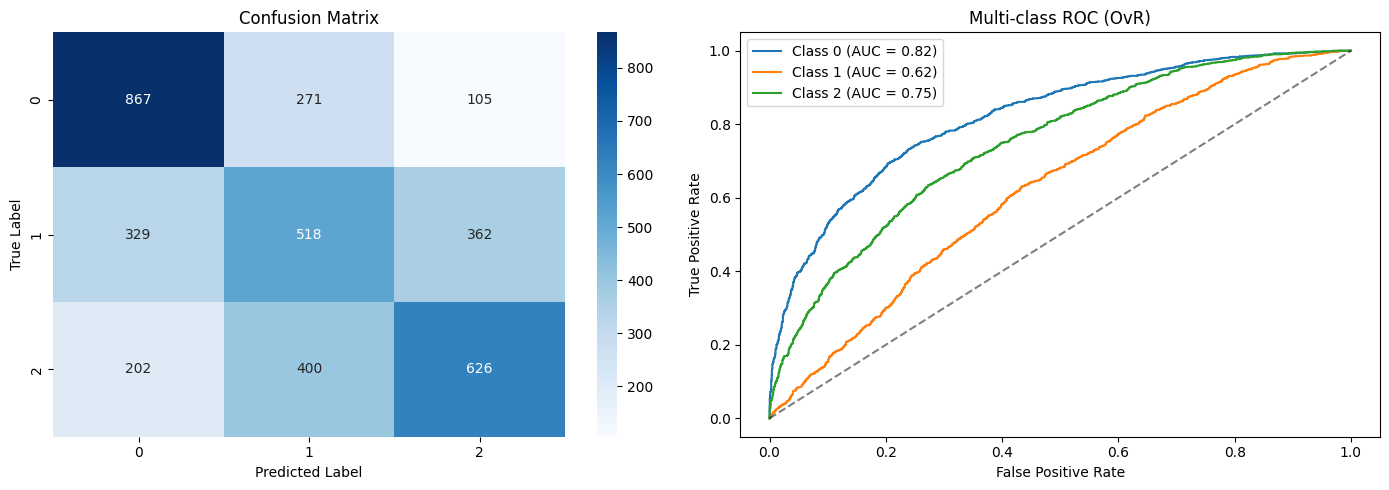

In [ ]:

df = pd.read_parquet("./datasets/amazon_user_reviews_text_sentiment_with_sw.parquet")

# Ensure correct columns
texts = df["original_text"].astype(str).values
labels = df["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

max_vocab_size = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding="post")


model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=128, input_length=max_length, mask_zero=True),
    SimpleRNN(128),
    Dense(128, activation="relu"),
    Dense(3, activation="softmax"),
    Dropout(0.2)
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=3,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)


# ModelEvaluation
from ModelEvaluation import ModelEvaluation
# Model Evaluation

preds = model.predict(X_test_pad)
y_pred = np.argmax(preds, axis=1)
evaluator = ModelEvaluation()
evaluator.run_pipeline(y_test, y_pred, preds)